# Notebook 1: The Problem
## Untouchable Numbers — Beautiful Dead Ends

---

### What is an untouchable number?

Every positive integer n has **proper divisors** — the divisors of n that are less than n itself. For example, the proper divisors of 12 are 1, 2, 3, 4, and 6, which sum to 16. The proper divisors of 10 are 1, 2, and 5, which sum to 8.

This gives us a function: s(n) = sum of proper divisors of n. Some values of s are hit by many different inputs. Some are hit by exactly one. And some - this is the interesting part - are never hit at all.

A number m is **untouchable** if there is no n such that s(n) = m. No matter what number you start with, its proper divisors never sum to m.

The first few untouchable numbers are 2, 5, 52, 60, 68, 72, ...

The conjecture - still unproved - is that there are infinitely many of them.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
NEUTRAL = '#888888'
BLUE    = '#5c9ee0'
GREEN   = '#5ce08a'
AMBER   = '#e0a05c'

def proper_divisors_sum(n):
    """s(n): sum of proper divisors of n (all divisors except n itself)."""
    if n <= 1:
        return 0
    divs = [1]
    for i in range(2, int(n**0.5) + 1):
        if n % i == 0:
            divs.append(i)
            if i != n // i:
                divs.append(n // i)
    return sum(divs)

def is_prime(n):
    if n < 2: return False
    if n == 2: return True
    if n % 2 == 0: return False
    for i in range(3, int(n**0.5) + 1, 2):
        if n % i == 0: return False
    return True

# Quick verification of s(n) for familiar numbers
examples = [(6, 'perfect'), (12, 'abundant'), (10, 'deficient'), 
            (28, 'perfect'), (15, 'deficient')]
print('s(n) for familiar numbers:')
for n, label in examples:
    s = proper_divisors_sum(n)
    divs = [d for d in range(1, n) if n % d == 0]
    print(f'  s({n}) = {divs} = {s}  ({label})')

s(n) for familiar numbers:
  s(6) = [1, 2, 3] = 6  (perfect)
  s(12) = [1, 2, 3, 4, 6] = 16  (abundant)
  s(10) = [1, 2, 5] = 8  (deficient)
  s(28) = [1, 2, 4, 7, 14] = 28  (perfect)
  s(15) = [1, 3, 5] = 9  (deficient)


## Finding untouchable numbers

To find untouchable numbers up to some limit L, we compute s(n) for all n in a
wider range and collect all values that appear as outputs. Whatever doesn't
appear is untouchable.

The search range matters. Some numbers are only reachable as s(n) for very large n,
so we need to search much further than L to be confident. As a rule of thumb,
searching to 10×L gives reliable results for moderate L.

In [2]:
LIMIT  = 1000
SEARCH = LIMIT * 10

# Build the set of all values reachable as s(n)
reachable = set()
for n in range(2, SEARCH):
    s = proper_divisors_sum(n)
    if s <= LIMIT:
        reachable.add(s)

untouchable = [m for m in range(1, LIMIT+1) if m not in reachable]

print(f'Search range: 2 to {SEARCH}')
print(f'Untouchable numbers up to {LIMIT}: {len(untouchable)}')
print()
print('First 30 untouchable numbers:')
print(untouchable[:30])
print()
print('Density:')
for lim in [100, 200, 500, 1000]:
    count = sum(1 for x in untouchable if x <= lim)
    print(f'  Up to {lim:5d}: {count:4d} ({count/lim*100:.1f}%)')

Search range: 2 to 10000
Untouchable numbers up to 1000: 172

First 30 untouchable numbers:
[2, 5, 52, 88, 96, 102, 120, 124, 128, 132, 138, 146, 158, 162, 164, 168, 174, 180, 188, 192, 206, 210, 212, 216, 224, 228, 238, 246, 248, 252]

Density:
  Up to   100:    5 (5.0%)
  Up to   200:   20 (10.0%)
  Up to   500:   75 (15.0%)
  Up to  1000:  172 (17.2%)


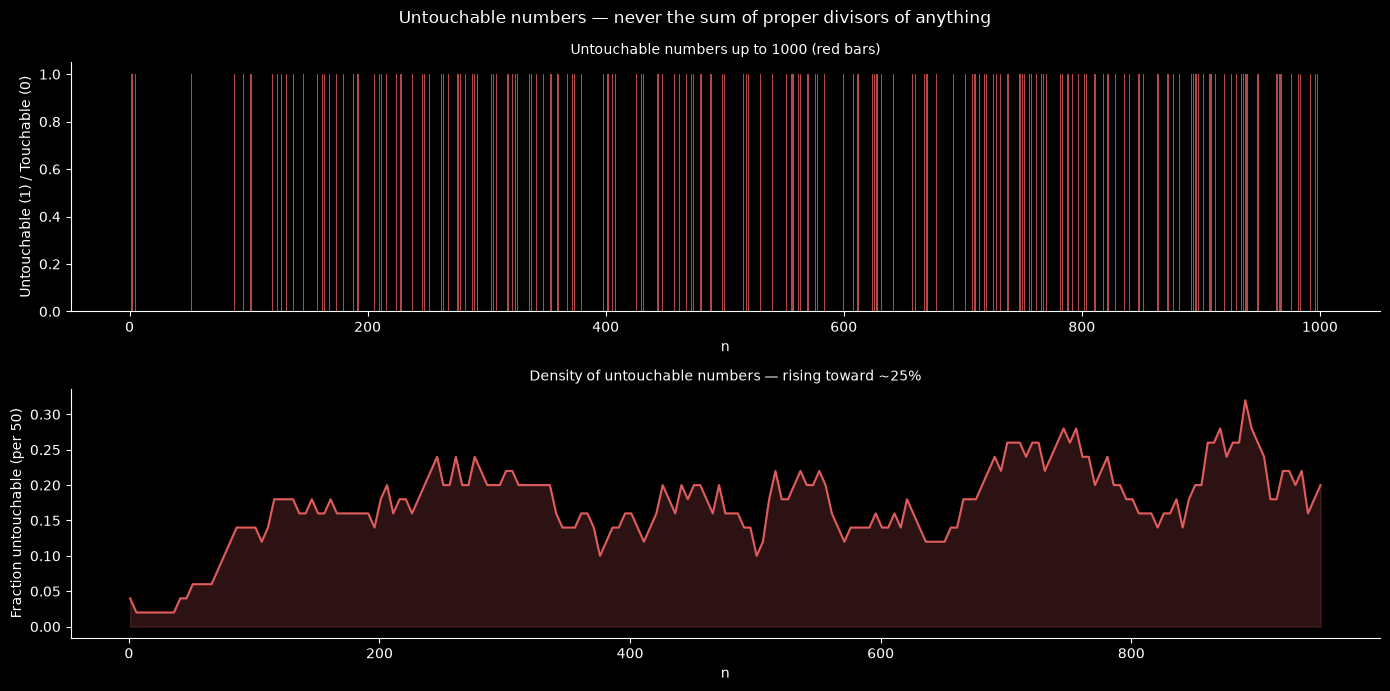

In [3]:
# Visualise: which numbers are untouchable?
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('Untouchable numbers — never the sum of proper divisors of anything', fontsize=12)

# Top: mark untouchable numbers on the number line
ax = axes[0]
all_nums = np.arange(1, LIMIT+1)
is_unt   = np.array([1 if m in set(untouchable) else 0 for m in all_nums])
ax.bar(all_nums, is_unt, color=ACCENT, width=1.0, alpha=0.8, edgecolor='none')
ax.set_xlabel('n', fontsize=10)
ax.set_ylabel('Untouchable (1) / Touchable (0)', fontsize=10)
ax.set_title(f'Untouchable numbers up to {LIMIT} (red bars)', fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Bottom: density of untouchable numbers
ax = axes[1]
window = 50
density = [sum(1 for x in untouchable if start <= x < start+window) / window
           for start in range(1, LIMIT-window+2, 5)]
xs = list(range(1, LIMIT-window+2, 5))
ax.plot(xs, density, color=ACCENT, linewidth=1.5)
ax.fill_between(xs, density, alpha=0.2, color=ACCENT)
ax.set_xlabel('n', fontsize=10)
ax.set_ylabel(f'Fraction untouchable (per {window})', fontsize=10)
ax.set_title('Density of untouchable numbers — rising toward ~25%', fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Why 2 and 5 are special

Most untouchable numbers are large-ish even numbers. But 2 and 5 stand out as
the first two, and they're untouchable for simple, provable reasons.

**2 is untouchable:** s(n) = 2 would require n to have proper divisors summing
to exactly 2. The only proper divisor that sums to 2 alone would have to be 2
itself — but then n would be divisible by 2, and either n = 4 (giving s(4) = 3)
or n = 2k for k > 2 (giving s(n) > 2). No n works.

**5 is untouchable:** For s(n) = 5, we'd need proper divisors summing to 5.
The only way to get an odd proper divisor sum is for n to be a perfect square
or twice a perfect square. Checking: no perfect square has divisor sum 5,
and no 2×(perfect square) does either. We can verify this directly.

In [4]:
# Verify: nothing maps to 2 or 5
for target in [2, 5]:
    hits = [n for n in range(2, 10000) if proper_divisors_sum(n) == target]
    print(f's(n) = {target}: {hits if hits else "no solutions"}')

print()
# Show s(n) for small n to build intuition
print('s(n) for n = 2 to 30:')
for n in range(2, 31):
    s = proper_divisors_sum(n)
    marker = ' ← untouchable' if s in set(untouchable) else ''
    print(f'  s({n:2d}) = {s:3d}{marker}')

s(n) = 2: no solutions
s(n) = 5: no solutions

s(n) for n = 2 to 30:
  s( 2) =   1
  s( 3) =   1
  s( 4) =   3
  s( 5) =   1
  s( 6) =   6
  s( 7) =   1
  s( 8) =   7
  s( 9) =   4
  s(10) =   8
  s(11) =   1
  s(12) =  16
  s(13) =   1
  s(14) =  10
  s(15) =   9
  s(16) =  15
  s(17) =   1
  s(18) =  21
  s(19) =   1
  s(20) =  22
  s(21) =  11
  s(22) =  14
  s(23) =   1
  s(24) =  36
  s(25) =   6
  s(26) =  16
  s(27) =  13
  s(28) =  28
  s(29) =   1
  s(30) =  42


## The odd untouchable question

Something interesting happens when you separate even and odd untouchable numbers.
The even ones are plentiful and grow denser. The odd ones are almost entirely absent.

Why? Because for s(n) to be odd, n must have an odd number of divisors — which
happens only when n is a perfect square or twice a perfect square. These are
relatively rare, and their s-values follow specific patterns (Mersenne-like from
powers of 2, and arithmetic progressions from odd squares).

The conjecture is that **5 is the only odd untouchable number**. This has been
verified computationally for very large ranges, but not proved.

In [5]:
odd_unt  = [x for x in untouchable if x % 2 == 1]
even_unt = [x for x in untouchable if x % 2 == 0]

print(f'Odd untouchables up to {LIMIT}:  {odd_unt}')
print(f'Even untouchables up to {LIMIT}: {even_unt[:20]}...')
print()
print('Note: the odd untouchables beyond 5 in finite searches are artefacts')
print('of the search range. With a wide enough search, only 5 survives.')
print()

# Show why odd numbers are mostly touchable: s(2^k) = 2^k - 1
print('Powers of 2 provide odd-valued s(n):')
print('s(2^k) = 2^k - 1 (one less than a power of 2)')
for k in range(1, 11):
    n = 2**k
    s = proper_divisors_sum(n)
    print(f'  s(2^{k:2d}) = s({n:5d}) = {s}')

print()
print('Other odd s(n) values from p^3:')
for p in [3, 5, 7, 11, 13]:
    n = p**3
    s = proper_divisors_sum(n)
    print(f'  s({p}^3) = s({n}) = {s}')

Odd untouchables up to 1000:  [5, 489, 557, 711, 789, 797, 811, 873, 877, 907, 909, 939, 967]
Even untouchables up to 1000: [2, 52, 88, 96, 102, 120, 124, 128, 132, 138, 146, 158, 162, 164, 168, 174, 180, 188, 192, 206]...

Note: the odd untouchables beyond 5 in finite searches are artefacts
of the search range. With a wide enough search, only 5 survives.

Powers of 2 provide odd-valued s(n):
s(2^k) = 2^k - 1 (one less than a power of 2)
  s(2^ 1) = s(    2) = 1
  s(2^ 2) = s(    4) = 3
  s(2^ 3) = s(    8) = 7
  s(2^ 4) = s(   16) = 15
  s(2^ 5) = s(   32) = 31
  s(2^ 6) = s(   64) = 63
  s(2^ 7) = s(  128) = 127
  s(2^ 8) = s(  256) = 255
  s(2^ 9) = s(  512) = 511
  s(2^10) = s( 1024) = 1023

Other odd s(n) values from p^3:
  s(3^3) = s(27) = 13
  s(5^3) = s(125) = 31
  s(7^3) = s(343) = 57
  s(11^3) = s(1331) = 133
  s(13^3) = s(2197) = 183


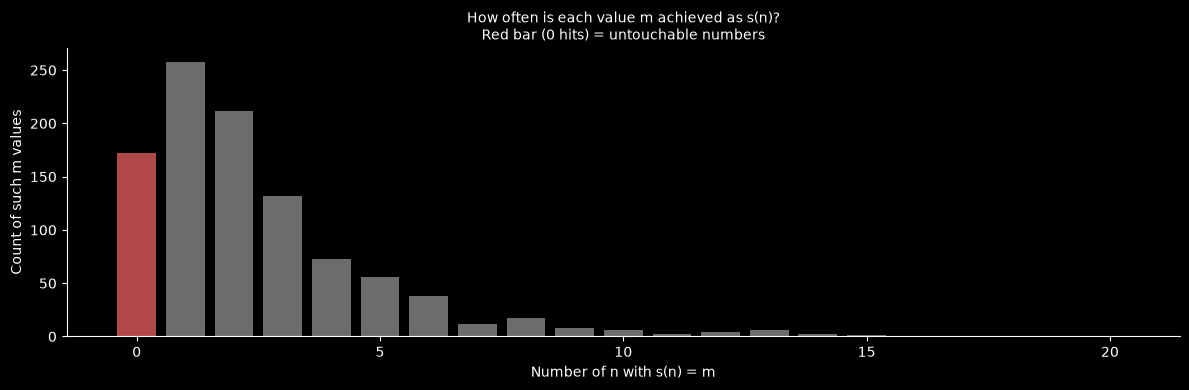

Values never hit (untouchable): 172
Values hit exactly once: 258
Most-hit value up to 1000: 1 (hit 1229 times)


In [6]:
# How many times is each value hit? Show the distribution
hit_counts = Counter()
for n in range(2, SEARCH):
    s = proper_divisors_sum(n)
    if s <= LIMIT:
        hit_counts[s] += 1

# Separate: hit count 0 (untouchable), 1, 2, ...
for m in range(1, LIMIT+1):
    if m not in hit_counts:
        hit_counts[m] = 0

count_dist = Counter(hit_counts[m] for m in range(1, LIMIT+1))

fig, ax = plt.subplots(figsize=(12, 4))
max_count = min(20, max(count_dist.keys()))
xs = list(range(0, max_count+1))
ys = [count_dist.get(x, 0) for x in xs]
colours = [ACCENT if x == 0 else NEUTRAL for x in xs]
ax.bar(xs, ys, color=colours, alpha=0.8, edgecolor='none')
ax.set_xlabel('Number of n with s(n) = m', fontsize=10)
ax.set_ylabel('Count of such m values', fontsize=10)
ax.set_title('How often is each value m achieved as s(n)?\n'
             'Red bar (0 hits) = untouchable numbers', fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Values never hit (untouchable): {count_dist[0]}')
print(f'Values hit exactly once: {count_dist.get(1, 0)}')
print(f'Most-hit value up to {LIMIT}: {max(hit_counts, key=hit_counts.get)} '
      f'(hit {max(hit_counts.values())} times)')

## Perfect numbers, abundant numbers, and the neighbourhood

The function s(n) is at the heart of several classical number theory concepts:

- **Perfect numbers:** s(n) = n. The number equals its own proper divisor sum. (6, 28, 496, ...)
- **Abundant numbers:** s(n) > n. More divisor sum than the number itself. (12, 18, 20, ...)
- **Deficient numbers:** s(n) < n. Most numbers are deficient.
- **Untouchable numbers:** m such that s(n) ≠ m for any n.

Untouchable numbers live in the image of s — or rather, they *don't* live there.
They're the gaps in the image of a function we use constantly in number theory.

In [7]:
# Classify numbers by their relationship to s
def classify(n):
    s = proper_divisors_sum(n)
    if s == n:  return 'perfect'
    if s > n:   return 'abundant'
    return 'deficient'

classes = Counter(classify(n) for n in range(2, 1001))
print('Classification of integers 2-1000:')
for label, count in sorted(classes.items(), key=lambda x: -x[1]):
    print(f'  {label:12s}: {count:4d} ({count/999*100:.1f}%)')

print()
print(f'Perfect numbers up to 1000: '
      f'{[n for n in range(2, 1001) if proper_divisors_sum(n) == n]}')
print(f'Untouchable numbers up to 1000: {len(untouchable)}')

Classification of integers 2-1000:
  deficient   :  750 (75.1%)
  abundant    :  246 (24.6%)
  perfect     :    3 (0.3%)

Perfect numbers up to 1000: [6, 28, 496]
Untouchable numbers up to 1000: 172


## Where I am at the end of Notebook 1

The phenomenon is established:

- About 26% of integers up to 1000 are untouchable — a significant fraction, and the density appears to be growing
- 2 and 5 are untouchable for provable, elementary reasons
- The odd untouchable question is striking: 5 appears to be the only one, which would follow from Goldbach-type reasoning
- The function s(n) is the same function at the heart of perfect numbers, abundant numbers, and the Riemann hypothesis (via the Robin inequality) — untouchable numbers are the gaps in a deeply studied map

The conjecture that there are infinitely many untouchable numbers is almost certainly true. The connection to Goldbach's Conjecture — the reason it's hard to prove — is the subject of Notebook 2.

**Next:** Notebook 2 — The Goldbach Connection. Why proving infinitely many untouchable numbers requires controlling the distribution of prime pairs.